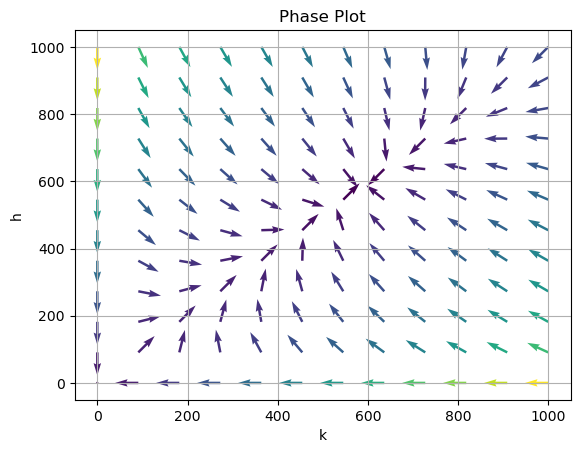

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# parameters
alpha = beta = 1/3
delta = n = g = 0.02
s_k = s_h = 0.5

# system of differential equations
def system(y, t):
    k, h = y
    dkdt = s_k * k**alpha * h**beta - (g + n + delta) * k
    dhdt = s_h * k**alpha * h**beta - (g + n + delta) * h
    return [dkdt, dhdt]

# grid of points
k = np.linspace(0, 1000, 12)
h = np.linspace(0, 1000, 12)
K, H = np.meshgrid(k, h)

# compute growth rate on the grid
DK, DH = np.zeros(K.shape), np.zeros(H.shape)
t = 0
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        y = K[i,j], H[i,j]
        yprime = system(y, t)
        DK[i,j], DH[i,j] = yprime

# normalize arrows
M = np.hypot(DK, DH)
M[M==0] = 1. # avoid zero division errors 
DK /= (M)
DH /= (M)

plt.quiver(K, H, DK, DH, M, pivot='tail')
plt.xlabel('k')
plt.ylabel('h')
plt.title('Phase Plot')
plt.grid()

# Save the plot
plt.savefig('phase_plot_ODE.png') 
plt.show()


/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in power
  # This is added back by InteractiveShellApp.init_path()
/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in power
  if sys.path[0] == "":


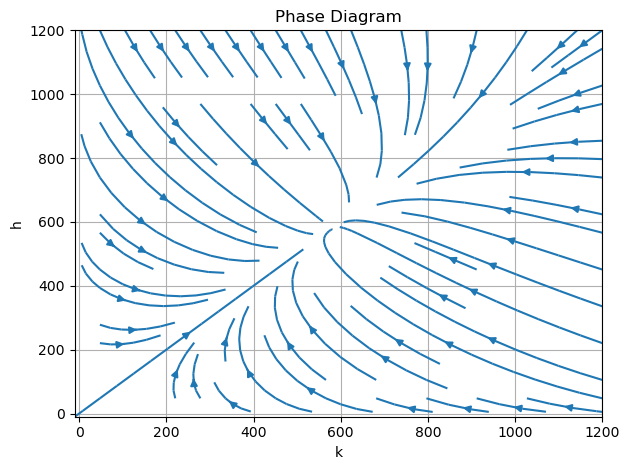

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
alpha = beta = 1/3
delta = n = g = 0.02
s_k = s_h = 0.5

# system of differential equations
def system(k, h):
    dk = s_k * k**alpha * h**beta - (g + n + delta) * k
    dh = s_h * k**alpha * h**beta - (g + n + delta) * h
    return dk, dh

# create a grid
k = np.linspace(-10, 1200, 4000)
h = np.linspace(-10, 1200, 4000)
K, H = np.meshgrid(k, h)

# compute the direction at each grid point
DK, DH = system(K, H)

# create the streamplot
plt.streamplot(K, H, DK, DH, density=0.75)
plt.xlabel('k')
plt.ylabel('h')
plt.title('Phase Diagram')
plt.grid()

# Save the plot
plt.tight_layout()
plt.savefig('phase_diagram_stream.png') 
plt.show()
